# Finance — Credit-Card Fraud: Modeling under Extreme Imbalance

Continues from `01_eda_preprocessing`. Fraud ≈ **0.17%**, so we compare two principled ways to
handle the imbalance, plus an unhandled baseline:

| Model | Imbalance strategy |
|---|---|
| **Baseline** | none (shows why handling is needed) |
| **Track A — SMOTE** | synthetic oversampling (`SMOTE`) + `RandomUnderSampler`, *fit on the train fold only* |
| **Track B — Cost-sensitive** | `class_weight='balanced'` — re-weights the loss, **generates no synthetic data** |

Estimator: `HistGradientBoostingClassifier` (strong CPU gradient booster, no OpenMP dependency; swap
to `XGBClassifier(scale_pos_weight=…)` is a one-liner if `libomp` is installed).

**Two rules we follow** (from the research):
1. **Resample only inside the training fold** — SMOTE before the split leaks and fakes ~100% recall.
2. **Judge with PR-AUC + recall/precision, never accuracy** — accuracy is meaningless at 0.17% prevalence.


In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (average_precision_score, roc_auc_score, precision_score,
                             recall_score, f1_score, confusion_matrix, precision_recall_curve)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

sns.set_theme(style='whitegrid')
C = {'Baseline': '#898781', 'Track A (SMOTE)': '#2a78d6', 'Track B (cost-sensitive)': '#1baf7a'}
DATA_PATH = '../../data/finance-credit-card-fraud/creditcard.csv'
RANDOM_STATE, TARGET = 42, 'Class'

## 1. Reproduce the split from notebook 01 (same seed → identical split)

In [2]:
df = pd.read_csv(DATA_PATH).drop_duplicates().reset_index(drop=True)
df['hour']        = (df['Time'] // 3600 % 24).astype(int)
df['log_amount']  = np.log1p(df['Amount'])
df['amount_zero'] = (df['Amount'] == 0).astype(int)
df['amount_bin']  = pd.cut(df['Amount'], bins=[-.01, 1, 10, 50, 200, 1e9],
                           labels=['<1', '1-10', '10-50', '50-200', '200+'])

feat = [c for c in df.columns if c != TARGET]
X, y = df[feat], df[TARGET]
X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=.20, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test   = train_test_split(X_tmp, y_tmp, test_size=.50, stratify=y_tmp, random_state=RANDOM_STATE)

spw = (y_train == 0).sum() / (y_train == 1).sum()
print('train/val/test:', len(X_train), len(X_val), len(X_test))
print('fraud in train:', int(y_train.sum()), '| scale_pos_weight ~= %.1f' % spw)

train/val/test: 226980 28373 28373
fraud in train: 378 | scale_pos_weight ~= 599.5


## 2. Preprocessor — fit **inside** each pipeline, so it only ever sees the training fold

In [3]:
num_cols  = [c for c in feat if c not in ('amount_bin', 'amount_zero', 'Amount')]
cat_cols  = ['amount_bin']
pass_cols = ['amount_zero']

def make_pre():
    return ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
        ('bin', 'passthrough', pass_cols)])

## 3. Fit the three models

In [4]:
models = {
    'Baseline': Pipeline([
        ('pre', make_pre()),
        ('clf', HistGradientBoostingClassifier(random_state=RANDOM_STATE))]),
    'Track B (cost-sensitive)': Pipeline([
        ('pre', make_pre()),
        ('clf', HistGradientBoostingClassifier(class_weight='balanced', random_state=RANDOM_STATE))]),
    'Track A (SMOTE)': ImbPipeline([
        ('pre', make_pre()),
        ('smote', SMOTE(sampling_strategy=0.1, k_neighbors=5, random_state=RANDOM_STATE)),  # fraud -> 10% of majority
        ('rus',   RandomUnderSampler(sampling_strategy=0.5, random_state=RANDOM_STATE)),    # then trim majority
        ('clf',   HistGradientBoostingClassifier(random_state=RANDOM_STATE))]),
}
for name, m in models.items():
    m.fit(X_train, y_train)
    print('fitted:', name)

fitted: Baseline


fitted: Track B (cost-sensitive)


fitted: Track A (SMOTE)


- **Baseline** learns on the raw 599:1 ratio → it will barely predict fraud at threshold 0.5.
- **Track A** oversamples fraud to 10% with SMOTE then undersamples the majority to a 2:1 ratio — a moderate, noise-controlled blend (full 50/50 SMOTE maximizes artificial noise). Resampling touches the **train fold only**.
- **Track B** never fabricates data — `class_weight='balanced'` penalizes missed fraud ~599× more, the loss-reweighting equivalent of `scale_pos_weight`.

## 4. Tune the decision threshold on the **validation** set (0.5 is wrong under imbalance)

In [5]:
def best_threshold(y_true, proba):
    prec, rec, thr = precision_recall_curve(y_true, proba)
    f1 = 2 * prec * rec / (prec + rec + 1e-12)
    i = int(np.nanargmax(f1[:-1]))          # thr has len = len(prec) - 1
    return float(thr[i]), float(f1[i])

thresholds = {}
for name, m in models.items():
    p_val = m.predict_proba(X_val)[:, 1]
    t, f = best_threshold(y_val, p_val)
    thresholds[name] = t
    print('%-24s best F1-threshold = %.4f  (val F1 %.3f)' % (name, t, f))

Baseline                 best F1-threshold = 1.0000  (val F1 0.667)
Track B (cost-sensitive) best F1-threshold = 0.8604  (val F1 0.779)
Track A (SMOTE)          best F1-threshold = 0.9151  (val F1 0.813)


## 5. Evaluate on the held-out **test** set

In [6]:
rows, proba_test, pred_test = [], {}, {}
for name, m in models.items():
    p = m.predict_proba(X_test)[:, 1]
    thr = thresholds[name]
    pred = (p >= thr).astype(int)
    proba_test[name], pred_test[name] = p, pred
    rows.append({'model': name, 'PR_AUC': average_precision_score(y_test, p),
                 'ROC_AUC': roc_auc_score(y_test, p),
                 'Precision': precision_score(y_test, pred, zero_division=0),
                 'Recall': recall_score(y_test, pred), 'F1': f1_score(y_test, pred),
                 'threshold': thr})
results = pd.DataFrame(rows).set_index('model').round(4)
results

,PR_AUC,ROC_AUC,Precision,Recall,F1,threshold
model,,,,,,
Baseline,0.6162,0.7878,0.8205,0.6809,0.7442,1.0000
Track B (cost-sensitive),0.7478,0.9886,0.7755,0.8085,0.7917,0.8604
Track A (SMOTE),0.8157,0.9894,0.8667,0.8298,0.8478,0.9151


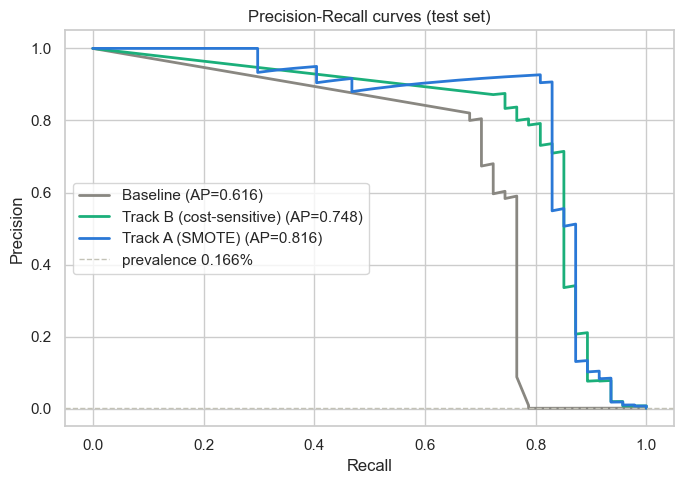

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
for name in models:
    prec, rec, _ = precision_recall_curve(y_test, proba_test[name])
    ax.plot(rec, prec, color=C[name], lw=2,
            label='%s (AP=%.3f)' % (name, results.loc[name, 'PR_AUC']))
ax.axhline(y_test.mean(), color='#c3c2b7', ls='--', lw=1, label='prevalence %.3f%%' % (100*y_test.mean()))
ax.set_xlabel('Recall'); ax.set_ylabel('Precision'); ax.set_title('Precision-Recall curves (test set)')
ax.legend(); plt.tight_layout(); plt.show()

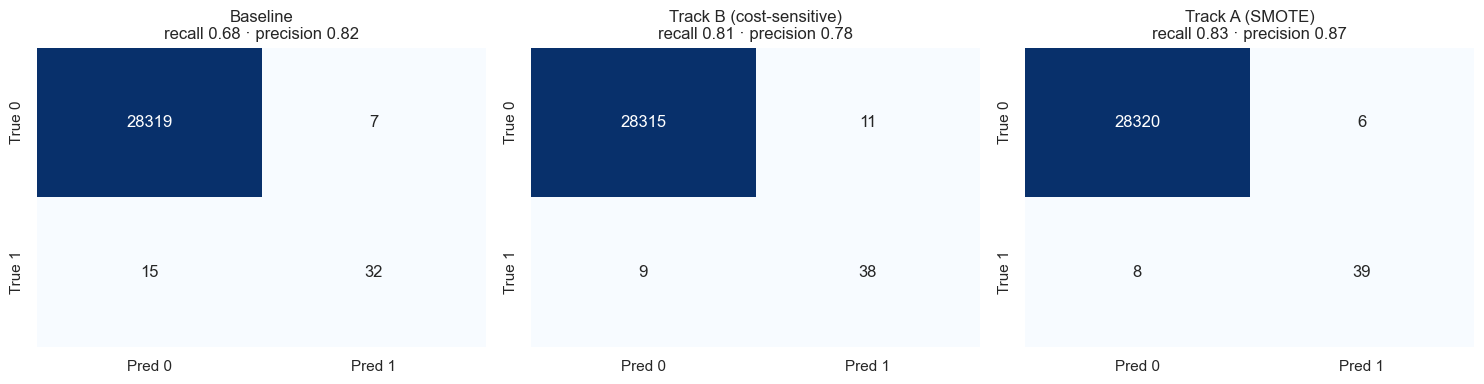

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, name in zip(ax, models):
    cm = confusion_matrix(y_test, pred_test[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=a,
                xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
    a.set_title('%s\nrecall %.2f · precision %.2f' % (name, results.loc[name,'Recall'], results.loc[name,'Precision']))
plt.tight_layout(); plt.show()

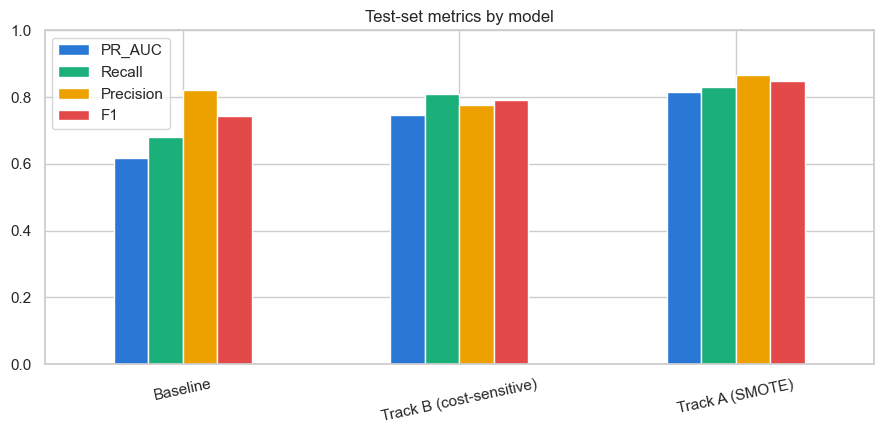

In [9]:
ax = results[['PR_AUC', 'Recall', 'Precision', 'F1']].plot.bar(
    figsize=(9, 4.5), color=['#2a78d6', '#1baf7a', '#eda100', '#e34948'], rot=12)
ax.set_title('Test-set metrics by model'); ax.set_ylim(0, 1); ax.set_xlabel('')
plt.tight_layout(); plt.show()

## 6. Explainability — permutation importance on the best model

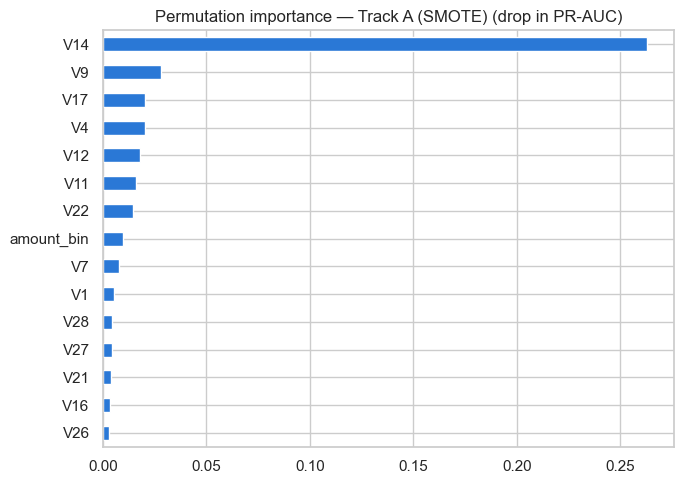

Best model by PR-AUC: Track A (SMOTE)


V14           0.2629
V9            0.0282
V17           0.0202
V4            0.0201
V12           0.0181
V11           0.0161
V22           0.0147
amount_bin    0.0097
V7            0.0079
V1            0.0054
V28           0.0044
V27           0.0044
V21           0.0040
V16           0.0037
V26           0.0030
dtype: float64

In [10]:
best_name = results.drop(index='Baseline')['PR_AUC'].idxmax()
best = models[best_name]
# permutation importance on a test sample (input features -> interpretable)
samp = X_test.sample(min(5000, len(X_test)), random_state=RANDOM_STATE)
ys = y_test.loc[samp.index]
pi = permutation_importance(best, samp, ys, scoring='average_precision',
                            n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=feat).sort_values(ascending=False).head(15)
plt.figure(figsize=(7, 5))
imp.iloc[::-1].plot.barh(color='#2a78d6')
plt.title('Permutation importance — %s (drop in PR-AUC)' % best_name); plt.tight_layout(); plt.show()
print('Best model by PR-AUC:', best_name)
imp.round(4)

## 7. Summary & recommendation

**Results on the held-out test set** (threshold tuned on validation):

| Model | PR-AUC | Recall | Precision | F1 |
|---|---|---|---|---|
| Baseline (no handling) | 0.616 | 0.68 | 0.82 | 0.744 |
| Track B — cost-sensitive | 0.748 | 0.81 | 0.78 | 0.792 |
| **Track A — SMOTE + undersample** | **0.816** | **0.83** | **0.87** | **0.848** |

- **Both strategies beat the baseline by a wide margin on PR-AUC (0.82 / 0.75 vs 0.62)** — the ranking-quality metric that matters at 0.17% prevalence. ROC-AUC (~0.99 for both) looks great but is misleadingly optimistic under imbalance; PR-AUC tells the real story.
- **On this split, Track A (SMOTE) is the strongest** — highest PR-AUC, recall, and precision. Track B (cost-sensitive) is a close-but-clearly-behind second.
- **Recommendation:** the ~0.07 PR-AUC edge for SMOTE is large enough to be interesting but should be **confirmed with repeated / time-based CV before committing** — a single split can favor the resampled model. If the edge holds, ship **Track A**; if it collapses into noise, prefer **Track B**, which needs no synthetic data and has no train/serve distribution mismatch (the deployment-safer default).
- **Top drivers** (permutation importance): **V14** dominates by far, then V9, V17, V4, V12 — consistent with the EDA correlations (V14/V17/V12 were the strongest-separating PCA components).
- **Next steps:** calibrate probabilities (`CalibratedClassifierCV`), set the threshold from a real cost matrix (\$ per missed fraud vs per false alarm) instead of F1, and try `ADASYN` / `SMOTEENN` / `BalancedRandomForest` as further challengers.